### Here, we merge two data sources for microRNA expression data (microarray and NGS), then filter them for various confounders and predict expected expression values.

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import ast
import os

In [120]:
# get data
microarray_df = pd.read_csv("microrna_data/microarray_cell_lines.csv", index_col=0)
ngs_df = pd.read_csv("microrna_data/ngs_cell_lines.csv", index_col=0)

common_columns = list(set(microarray_df.columns).intersection(set(ngs_df.columns)))
print("Common columns:", common_columns)
microarray_df = microarray_df[common_columns]
ngs_df = ngs_df[common_columns]

Common columns: ['HEK293T', 'DG75', 'A549', 'HUH7', 'JEG3', 'Tera1', 'SKNSH', 'PC3', 'HaCaT', 'Jurkat', 'MCF7', 'HeLa']


### Normalize and merge data

In [121]:
# get and filter to likely real mirnas
with open("microrna_data/likely_real_mirnas.pkl", "rb") as f:
    likely_real_mirnas = pickle.load(f)
    
microarray_df = microarray_df[microarray_df.index.isin(likely_real_mirnas)]
ngs_df = ngs_df[ngs_df.index.isin(likely_real_mirnas)]

common_index = microarray_df.index.intersection(ngs_df.index)
print("Number of common miRNAs:", len(common_index))
microarray_df = microarray_df.loc[common_index]
ngs_df = ngs_df.loc[common_index]

Number of common miRNAs: 1027


In [122]:
# normalize to rpm
from utils.mirna_levels import normalize_expr_df_to_rpm
microarray_df = normalize_expr_df_to_rpm(microarray_df, minimum=1)
ngs_df = normalize_expr_df_to_rpm(ngs_df, minimum=1)

# log it
ngs_df = np.log10(ngs_df)
microarray_df = np.log10(microarray_df)

In [123]:
# filter false positives and negatives for this dataset
# skip if unknown for the method
false_pos_and_neg = pd.read_excel("Supplementary Tables.xlsx", sheet_name="S7 - False pos. and neg.")
microarray_fpan = false_pos_and_neg[false_pos_and_neg["Type"].str.contains("microarray")]
microarray_fpan = microarray_fpan['microRNAs'].to_list()
microarray_fpan = [m.strip() for x in microarray_fpan for m in x.split(", ")]

ngs_fpan = false_pos_and_neg[false_pos_and_neg["Type"].str.contains("ngs")]
ngs_fpan = ngs_fpan['microRNAs'].to_list()
ngs_fpan = [m.strip() for x in ngs_fpan for m in x.split(", ")]

In [124]:
# get the geometric mean
merged_df = []
for mirna in microarray_df.index:
    microarray_values = microarray_df.loc[mirna].values
    ngs_values = ngs_df.loc[mirna].values
    
    # filter out false positives and negatives
    if mirna in microarray_fpan and mirna in ngs_fpan:
        continue # skip this one
    elif mirna in microarray_fpan:
        values = ngs_values
    elif mirna in ngs_fpan:
        values = microarray_values
    else:
        values = (ngs_values + microarray_values) / 2 # average if both are good 
    
    merged_df.append(values)
merged_df = pd.DataFrame(merged_df, index=microarray_df.index, columns=microarray_df.columns)

### Crosstalk, homopolymer, GC content, and polyA signal filtering

In [125]:
MATCH_DICT = {"A": "T", "T": "A", "C": "G", "G": "C"}
WOBBLE_DICT = {"A": "", "T": "G", "C": "", "G": "T"}

def get_pattern(target_seq, mirna_seq):
    # target_seq should already be reversed before entering this function
    pattern = []
    for i in range(len(target_seq)):
        t = target_seq[i]
        m = mirna_seq[i]
        if i == 0 and t == "A" and m != "T":
            pattern.append(0)
        elif MATCH_DICT.get(m) == t:
            pattern.append(0)
        elif WOBBLE_DICT.get(m) == t:
            pattern.append(2)
        else:
            pattern.append(1)
    return pattern

def get_median_mut_classification(input_df, impact_df):
    df = input_df.copy()
    position_columns = [col for col in df.columns if "pos_" in col]
    
    for index, row in df.iterrows():
        # get all mutation positions
        positions_mut = []
        for col in position_columns:
            if row[col] == 1:
                positions_mut.append(col)
                
        # get all wobble positions
        positions_wobble = []
        for col in position_columns:
            if row[col] == 2:
                positions_wobble.append(col)
                
        no_high_impact = 0
        no_mid_impact = 0
        no_low_impact = 0
        no_no_impact = 0
        
        for pos in positions_mut:
            if impact_df.loc[pos, "mismatch"] == "high":
                no_high_impact += 1
            elif impact_df.loc[pos, "mismatch"] == "mid":
                no_mid_impact += 1
            elif impact_df.loc[pos, "mismatch"] == "low":
                no_low_impact += 1
            elif impact_df.loc[pos, "mismatch"] == "no":
                no_no_impact += 1
        for pos in positions_wobble:
            if impact_df.loc[pos, "wobble"] == "high":
                no_high_impact += 1
            elif impact_df.loc[pos, "wobble"] == "mid":
                no_mid_impact += 1
            elif impact_df.loc[pos, "wobble"] == "low":
                no_low_impact += 1
            elif impact_df.loc[pos, "wobble"] == "no":
                no_no_impact += 1
                
        df.loc[index, "no_high_impact"] = no_high_impact
        df.loc[index, "no_mid_impact"] = no_mid_impact
        df.loc[index, "no_low_impact"] = no_low_impact
        df.loc[index, "no_no_impact"] = no_no_impact
        df.loc[index, "no_total_impact"] = no_high_impact + no_mid_impact + no_low_impact + no_no_impact
    return df

impact_columns = ["no_high_impact", "no_mid_impact", "no_low_impact", "no_no_impact"]
full_crosstalk_dict = {}
position_columns = [f"pos_{i+1}" for i in range(21)]

# get the mutation impact info
mutation_impact_df = pd.read_csv("mutation_impact.csv", index_col=0)
impact_map = mutation_impact_df.to_dict('index')

# get mirbase
mirbase = pd.read_csv("microrna_data/mirbase_extended.csv")
mirbase['target_rev'] = mirbase['target'].str[::-1]
mirna_names = mirbase['miRNA'].tolist()
mirna_seqs = mirbase['sequence_norm'].tolist()
target_seqs = mirbase['target_rev'].tolist()

if os.path.exists("microrna_data/full_crosstalk_dict.pkl"):
    with open(os.path.join("microrna_data", "full_crosstalk_dict.pkl"), "rb") as file:
        full_crosstalk_dict = pickle.load(file)
else:
    total_rows = len(mirbase)
    for i in range(total_rows):
        if i % 100 == 0:
            print(f"Processing {i+1}/{total_rows}...")
        mirna_name = mirna_names[i]
        current_target = target_seqs[i]
        rows_data = []
        
        for j in range(total_rows):
            # 1. Get Pattern
            pattern = get_pattern(current_target, mirna_seqs[j])
            
            # 2. Calculate Impacts immediately (replaces get_median_mut_classification)
            counts = {"high": 0, "mid": 0, "low": 0, "no": 0}
            for pos_idx, val in enumerate(pattern):
                pos_key = f"pos_{pos_idx+1}"
                if val == 1: # mismatch
                    counts[impact_map[pos_key]['mismatch']] += 1
                elif val == 2: # wobble
                    counts[impact_map[pos_key]['wobble']] += 1
            
            # Combine pattern and counts into one row
            # total_impact is high + mid + low + no
            total_imp = sum(counts.values())
            res_row = pattern + [counts['high'], counts['mid'], counts['low'], counts['no'], total_imp]
            rows_data.append(res_row)
        
        # 3. Create DataFrame once per outer loop
        # We use mirna_names as the index so you don't lose the identity!
        res_df = pd.DataFrame(
            rows_data, 
            columns=position_columns + impact_columns + ["no_total_impact"],
            index=mirna_names 
        )
        full_crosstalk_dict[mirna_name] = res_df

    with open(os.path.join("microrna_data", "full_crosstalk_dict.pkl"), "wb") as file:
        pickle.dump(full_crosstalk_dict, file)

In [132]:
from utils.crosstalk import merge_identical_mirnas
from utils.transfer_functions import transfer_function_linear

def merge_identical_mirnas(df_expression, mirbase):
    """Merges identical miRNAs in the expression dataframe.
    Assumes log10 expression levels."""
    
    # First, we merge identical miRNAs
    mirbase["sequence_norm_short"] = mirbase["sequence_norm"].str[:18]

    # find out which miRNAs are identical
    mirna_groups = mirbase.groupby("sequence_norm_short").groups
    
    drop_mirnas = []
    # add their expression levels
    for key, group in mirna_groups.items():
        # filter the group to those that are in the expression dataframe
        group = [x for x in group if x in df_expression.index]
        if len(group) > 1:
            # get the expression levels
            expression_levels = df_expression.loc[group, :]
            # make them linear
            expression_levels = 10**expression_levels
            # sum them
            expression_levels = np.log10(expression_levels.sum(axis=0))
            # set all mirnas in the group to the summed expression levels
            for mirna in group:
                for column in df_expression.columns:
                    # is the original value NaN? skip!
                    if np.isnan(df_expression.loc[mirna, column]):
                        continue
                    df_expression.loc[mirna, column] = expression_levels[column]
            drop_mirnas.extend(group[1:])
    return df_expression, mirna_groups, drop_mirnas

def apply_mirna_filters(df_expression_orig, mirbase_df, popt, filter_subset=None):
    print("Initial number of miRNAs:", len(df_expression_orig))
    # Create DataFrame to track filtered miRNAs and reasons
    filtered_mirnas = pd.DataFrame(columns=["reason"])

    # ----------- merge identical miRNAs -----------
    merged_expression, groups, drop_mirnas = merge_identical_mirnas(df_expression_orig.copy(), mirbase_df)
    groups = [group for group in groups.values() if len(group) > 1]
    groups = list(set([item for sublist in groups for item in sublist]))
    groups = [x for x in groups if x in merged_expression.index]

    filtered_mirnas_merged = pd.DataFrame(index=drop_mirnas, columns=["reason"])
    filtered_mirnas_merged["reason"] = "merged identical"
    filtered_mirnas = pd.concat([filtered_mirnas, filtered_mirnas_merged])
    merged_expression = merged_expression[~merged_expression.index.isin(drop_mirnas)]
    print("After merging identical miRNAs:", len(merged_expression))
    
    # ----------- Calculate crosstalk -----------
    df_knockdown_predicted = np.log10((10**merged_expression).apply(lambda x: transfer_function_linear(x, popt)))  

    crosstalk_filter_df = pd.DataFrame(columns=merged_expression.columns, index=merged_expression.index)
    crosstalk_filter_df.loc[:, :] = False

    for key in full_crosstalk_dict.keys():
        if not key in df_knockdown_predicted.index:
            continue
        
        df = full_crosstalk_dict[key].copy()
        df = df[df.index != key]
        
        # check for total less than 5 mutations
        df = df[(df["no_total_impact"]) < 5]
        
        # check for high impact mutations
        df = df[df["no_high_impact"] < 2]
        
        # check for mid_impact mutations
        df = df[(df["no_mid_impact"]+df["no_high_impact"]) < 4]
        
        # check for all mutations
        df = df[(df["no_low_impact"]+df["no_mid_impact"]+df["no_high_impact"]) < 5]

        # add an expression row to the df
        df = df[df.index.isin(df_knockdown_predicted.index)]
        
        if len(df) > 0:
            df.loc[:, merged_expression.columns] = df_knockdown_predicted.loc[df.index, merged_expression.columns]
        else:
            continue
        
        # this is the knockdown across all remaining miRNAs after identifying those with likely crosstalk
        min_by_cell_line = df[merged_expression.columns].min(axis=0)
        
        # this is the expected knockdown for the miRNA itself
        knockdown_orig = df_knockdown_predicted.loc[key, merged_expression.columns]
        
        # we only filter if there is substantial expression of at least one of the potentially crosstalking miRNAs
        crosstalk_filter_df.loc[key, :] = ((10**knockdown_orig)/3 > 10**min_by_cell_line) & (min_by_cell_line < -0.3)

    # ----------- apply crosstalk filter -----------
    crosstalk_filter_dict = {}
    for cell_line in merged_expression.columns:
        crosstalk_filter_dict[cell_line] = list(crosstalk_filter_df[crosstalk_filter_df[cell_line] == True].index)

    # how often does each miRNA occur?
    crosstalk_filter_counts = pd.DataFrame(index=merged_expression.index, columns=merged_expression.columns)
    crosstalk_filter_counts.loc[:, :] = 0
    for mirna in merged_expression.index:
        for cell_line in merged_expression.columns:
            if filter_subset is not None:
                if cell_line not in filter_subset:
                    continue
            if mirna in crosstalk_filter_dict[cell_line]:
                crosstalk_filter_counts.loc[mirna, cell_line] = 1

    # filter miRNAs that experience crosstalk in at least two columns
    crosstalk_filter_mirnas = crosstalk_filter_counts.loc[crosstalk_filter_counts.sum(axis=1) > 1].index

    filtered_mirnas_crosstalk = pd.DataFrame(index=crosstalk_filter_mirnas, columns=["reason"])
    filtered_mirnas_crosstalk["reason"] = "crosstalk"
    filtered_mirnas = pd.concat([filtered_mirnas, filtered_mirnas_crosstalk])

    print("Filtering crosstalk")
    print(len(merged_expression))
    merged_expression = merged_expression[~merged_expression.index.isin(crosstalk_filter_mirnas)]
    print(len(merged_expression))

    # ----------- homopolymers -----------
    def find_longest_homopolymer(seq):
        max_length = 1
        current_length = 1
        for i in range(1, len(seq)):
            if seq[i] == seq[i-1]:
                current_length += 1
                max_length = max(max_length, current_length)
            else:
                current_length = 1
        return max_length

    mirbase_df["longest_homopolymer"] = mirbase_df["target"].apply(find_longest_homopolymer)
    long_homopolymer_mirnas = mirbase_df[mirbase_df["longest_homopolymer"] > 5]

    filtered_mirnas_homopolymer = pd.DataFrame(index=long_homopolymer_mirnas.index, columns=["reason"])
    filtered_mirnas_homopolymer["reason"] = "homopolymer"
    filtered_mirnas = pd.concat([filtered_mirnas, filtered_mirnas_homopolymer])

    print("Filtering homopolymers")
    print(len(merged_expression))
    merged_expression = merged_expression[~merged_expression.index.isin(long_homopolymer_mirnas.index)]
    print(len(merged_expression))

    # ----------- GC content -----------
    mirbase_df["GC_content"] = mirbase_df["sequence_norm"].apply(lambda x: (x.count('G') + x.count('C')) / len(x))
    high_GC_content_mirnas = mirbase_df[mirbase_df["GC_content"] > 0.75]

    filtered_mirnas_GC = pd.DataFrame(index=high_GC_content_mirnas.index, columns=["reason"])
    filtered_mirnas_GC["reason"] = "GC content"
    filtered_mirnas = pd.concat([filtered_mirnas, filtered_mirnas_GC])

    print("Filtering GC content")
    print(len(merged_expression))
    merged_expression = merged_expression[~merged_expression.index.isin(high_GC_content_mirnas.index)]
    print(len(merged_expression))

    # ----------- poly(A) signal -----------
    polyA_signals = ["AATAAA", "ATTAAA"]
    mirbase_df["polyA_signal"] = mirbase_df["target"].apply(lambda x: True if any(signal in x for signal in polyA_signals) else False)
    polyA_mirnas = mirbase_df[mirbase_df["polyA_signal"]].index

    filtered_mirnas_polyA = pd.DataFrame(index=polyA_mirnas, columns=["reason"])
    filtered_mirnas_polyA["reason"] = "poly(A) signal"
    filtered_mirnas = pd.concat([filtered_mirnas, filtered_mirnas_polyA])

    print("Filtering poly(A) signal")
    print(len(merged_expression))
    merged_expression = merged_expression[~merged_expression.index.isin(polyA_mirnas)]
    print(len(merged_expression))

    return merged_expression, filtered_mirnas, groups

# get the non-merged expression data
if 'miRNA' in mirbase.columns:
    mirbase.set_index("miRNA", inplace=True)
df_expression_orig = merged_df.copy()
popt = 3.7 # this is a good value for crosstalk filtering since it is ~always close to correct
df_expression_filtered, filtered_mirnas, merged_mirnas = apply_mirna_filters(df_expression_orig, mirbase, popt, filter_subset=None)

Initial number of miRNAs: 1027
After merging identical miRNAs: 1004
Filtering crosstalk
1004
986
Filtering homopolymers
986
976
Filtering GC content
976
956
Filtering poly(A) signal
956
951


In [167]:
df_expression_filtered.to_csv("microrna_data/merged_and_filtered_mirna_expression.csv")

## Verify proper processing by predicting on experimental data of the publication

In [155]:
df_expression_for_exp = df_expression_filtered.copy()

In [156]:
test_data = np.log10(pd.read_csv("stability_data/Data S4 - Library 2 normalized ratiometric stability data.csv", index_col=0))
design_1x = pd.read_csv("design/1_mirna_full_single_high_conf.csv", index_col=0)
test_data = test_data[test_data.index.isin(design_1x.index)]
test_data['miRNA'] = design_1x['miRNA1']
test_data = test_data.set_index('miRNA')

In [157]:
common_index = df_expression_for_exp.index.intersection(test_data.index)
print("Number of common miRNAs between filtered expression and test data:", len(common_index))
df_expression_for_exp = df_expression_for_exp.loc[common_index]
test_data = test_data.loc[common_index]

Number of common miRNAs between filtered expression and test data: 796


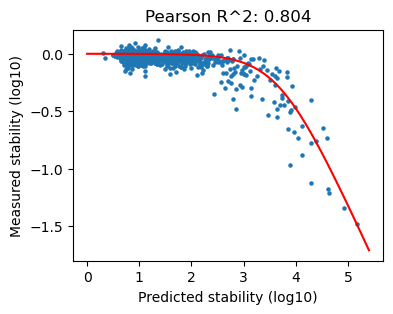

In [ ]:
# This should yield an R^2 of around 0.8

xvals_lin = 10**np.arange(0, 5.5, 0.1)
yvals_lin = transfer_function_linear(xvals_lin, popt)

x_vals_log = np.log10(xvals_lin)
y_vals_log = np.log10(yvals_lin)

y_vals_predicted = np.log10((10**df_expression_for_exp['HeLa']).apply(lambda x: transfer_function_linear(x, popt)))
r2 = np.corrcoef(y_vals_predicted, test_data['HeLa'])[0, 1] ** 2

plt.figure(figsize=(4, 3))
plt.scatter(df_expression_for_exp['HeLa'], test_data['HeLa'], s=5)
plt.plot(x_vals_log, y_vals_log, color='red', label='Transfer Function Fit')
plt.title("Pearson R^2: {:.3f}".format(r2))
plt.ylabel("Measured stability (log10)")
plt.xlabel("Predicted stability (log10)")
plt.show()